In [2]:
import pandas as pd
sales_df = pd.read_csv('sales_data_sample.csv', encoding="unicode_escape")
sales_df.head(1)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.7,2,2871.0,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small


In [3]:
revenue = sales_df.groupby('PRODUCTLINE')['SALES'].sum()
revenue = revenue.sort_values(ascending= False)
print("--- TOTAL REVENUE BY PRODUCT LINE ---")
print(revenue)

--- TOTAL REVENUE BY PRODUCT LINE ---
PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64


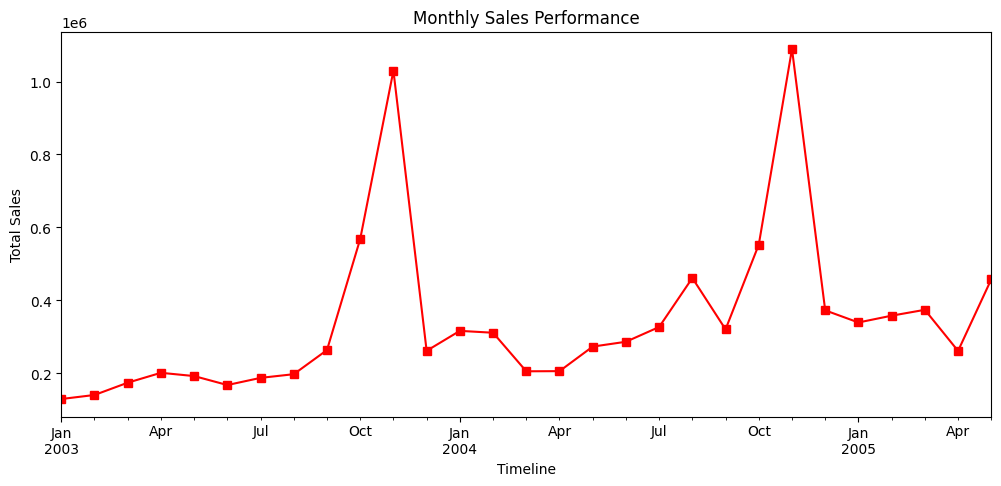

In [4]:
import matplotlib.pyplot as plt
sales_df['ORDERDATE'] = pd.to_datetime(sales_df['ORDERDATE'])
sales_df['YEAR_MONTH'] = sales_df['ORDERDATE'].dt.to_period('M')
monthly_sales = sales_df.groupby('YEAR_MONTH')['SALES'].sum() #grpup by new month coplumn and sum up the sales
monthly_sales.plot(kind='line', marker='s', color='red', figsize=(12,5))
plt.title("Monthly Sales Performance")
plt.xlabel("Timeline")
plt.ylabel("Total Sales")
plt.show()

<Axes: xlabel='COUNTRY'>

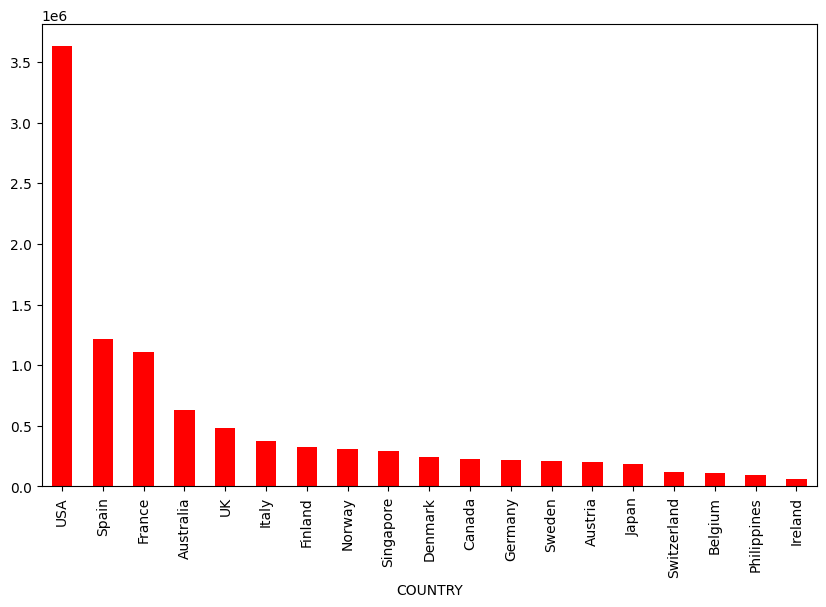

In [5]:
country = sales_df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)
country.plot(kind='bar', color='red', figsize=(10,6))